In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error

In [ ]:
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing()

In [ ]:
print(data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [ ]:
df = pd.DataFrame(data=data.data,columns = data.feature_names)

In [ ]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [ ]:
data.target

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

In [ ]:
df.shape

(20640, 8)

In [ ]:
df['target'] = data.target

In [ ]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [ ]:
shuffled_df = df.sample(frac=1).reset_index(drop=True).head(1000)

In [ ]:
shuffled_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,7.7197,16.0,17.500000,1.750000,17.0,4.250000,33.97,-118.43,5.00001
1,2.3359,24.0,4.994083,1.094675,1564.0,3.084813,37.10,-119.49,0.92400
2,0.4999,16.0,21.631579,6.000000,26.0,1.368421,39.42,-122.89,0.73500
3,1.7062,45.0,4.943503,1.048023,847.0,2.392655,37.26,-121.00,0.77400
4,1.5313,23.0,3.305000,1.018333,2048.0,3.413333,33.96,-118.28,0.91400
...,...,...,...,...,...,...,...,...,...
995,1.6250,32.0,4.582492,1.222222,1483.0,4.993266,35.38,-118.97,0.46800
996,1.9309,31.0,3.897303,1.143154,3288.0,3.410788,33.94,-118.33,1.37500
997,4.1346,26.0,5.626506,1.120482,244.0,2.939759,37.48,-121.02,1.87500
998,4.2383,18.0,7.572438,1.056537,828.0,2.925795,33.17,-117.32,2.39000


In [ ]:
X = shuffled_df.drop(['target'], axis=1)
y = shuffled_df['target']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 8), (200, 8), (800,), (200,))

In [ ]:
rt = DecisionTreeRegressor(random_state=0)
rt.fit(X=X_train, y=y_train)

DecisionTreeRegressor(random_state=0)

In [ ]:
y_pred_train = rt.predict(X_train)
y_pred_test = rt.predict(X_test)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
print('Training MSE:', mse_train)
print('Test MSE:', mse_test)

Training MSE: 0.0
Test MSE: 0.7898239969015001


In [ ]:
print('Tree depth:', rt.tree_.max_depth)
print('Tree node count:', rt.tree_.node_count)

Tree depth: 23
Tree node count: 1561


**# Cost Complexity Pruning**

In [ ]:
path = rt.cost_complexity_pruning_path(X_train, y_train)

In [ ]:
ccp_alphas, impurities = path.ccp_alphas, path.impurities

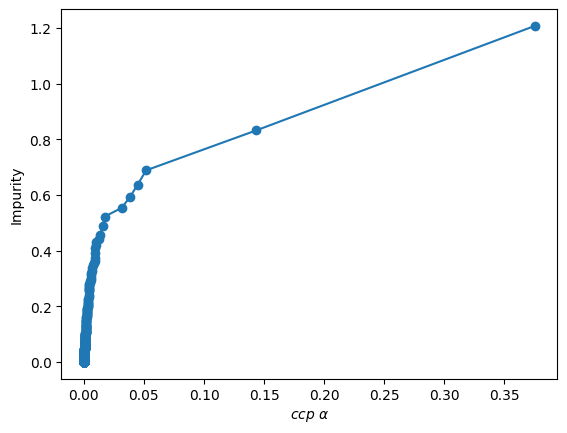

In [ ]:
plt.plot(ccp_alphas, impurities, marker = 'o')
plt.xlabel(r'$ccp~\alpha$')
plt.ylabel('Impurity')
plt.show()

In [ ]:
# Remove the last tree (only root), not useful for accuracy
ccp_alphas = np.unique(ccp_alphas)[:-1]
# ccp_alphas


In [ ]:
ccp_alphas

array([0.00000000e+00, 3.33066907e-18, 6.24999996e-10, 6.25000000e-10,
       6.25000000e-10, 6.25000000e-10, 2.50000000e-09, 2.50000000e-09,
       2.50000000e-09, 5.62500000e-09, 5.62500000e-09, 5.62500000e-09,
       5.62500000e-09, 5.62500000e-09, 5.62500000e-09, 1.00000000e-08,
       1.00000000e-08, 1.00000000e-08, 1.56250000e-08, 2.25000000e-08,
       2.25000000e-08, 2.25000000e-08, 2.25000000e-08, 3.06250000e-08,
       4.00000000e-08, 4.00000000e-08, 4.00000000e-08, 5.06250000e-08,
       6.25000000e-08, 6.25000000e-08, 6.25000000e-08, 6.25000000e-08,
       7.52083333e-08, 7.56250000e-08, 7.56250000e-08, 7.56250000e-08,
       7.56250000e-08, 9.00000000e-08, 9.00000000e-08, 9.00000000e-08,
       9.00000000e-08, 1.00833333e-07, 1.05625000e-07, 1.05625000e-07,
       1.22500000e-07, 1.22500000e-07, 1.22500000e-07, 1.40625000e-07,
       1.40625000e-07, 1.40625000e-07, 1.40625000e-07, 1.60000000e-07,
       1.60000000e-07, 1.60000000e-07, 1.63333333e-07, 1.63333333e-07,
      

In [ ]:
cv_mse = []  # Store results

# Compute cross-validated avg MSE for each candidate ccp_alpha
for alpha in ccp_alphas:
    dt = DecisionTreeRegressor(random_state=0, ccp_alpha=alpha)
    scores = cross_val_score(dt, X_train, y_train, cv=KFold(5, shuffle=True, random_state=0),
                             scoring='neg_mean_squared_error', n_jobs=5)
    cv_mse.append(np.mean(-scores))

In [ ]:
# Choose best alpha
best_alpha = ccp_alphas[np.argmin(cv_mse)]
print("Best alpha:", best_alpha)
print("Minimum CV_MSE:", np.min(cv_mse))

Best alpha: 0.010024541252616873
Minimum CV_MSE: 0.5813390424274891


Text(0, 0.5, 'Avg CV MSE')

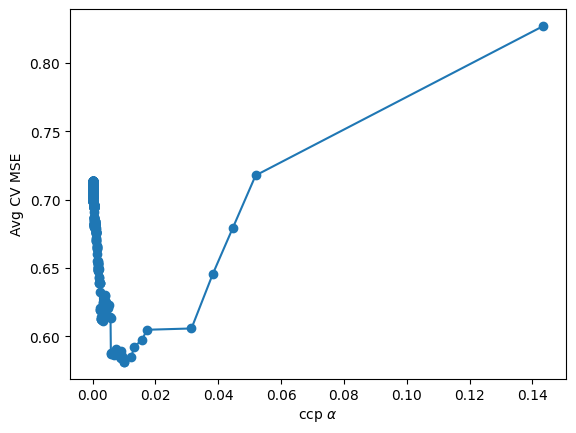

In [ ]:
plt.plot(ccp_alphas, cv_mse, marker = 'o')
plt.xlabel(r'ccp $\alpha$')
plt.ylabel('Avg CV MSE')

In [ ]:
best_alpha

np.float64(0.010024541252616873)

In [ ]:
# Fit final model with best alpha
final_tree = DecisionTreeRegressor(random_state=0, ccp_alpha=0.01002)
final_tree.fit(X_train, y_train)

DecisionTreeRegressor(ccp_alpha=0.01002, random_state=0)

In [ ]:
y_pred_train = final_tree.predict(X_train)
y_pred_test = final_tree.predict(X_test)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
print('Training MSE:', mse_train)
print('Test MSE:', mse_test)

Training MSE: 0.41022566328101484
Test MSE: 0.39732885490088116


In [ ]:
print('Tree depth:', final_tree.tree_.max_depth)
print('Tree node count:', final_tree.tree_.node_count)

Tree depth: 6
Tree node count: 29


In [ ]:
clfs = []
for alpha in ccp_alphas:
    clf = DecisionTreeRegressor(ccp_alpha=alpha, random_state=0)
    clf.fit(X_train, y_train)
    clfs.append(clf)

In [ ]:
node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]

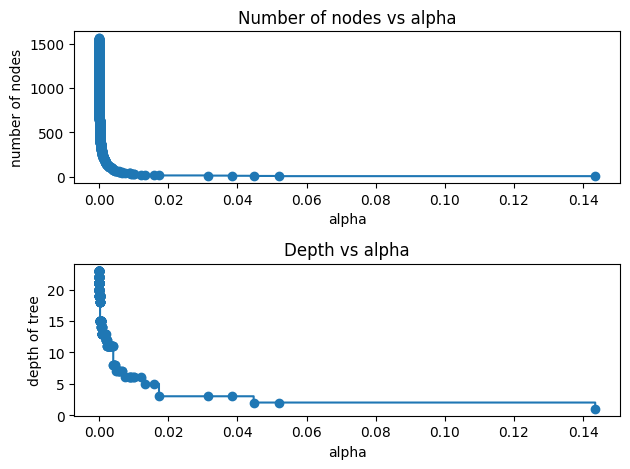

In [ ]:
fig, ax = plt.subplots(2, 1)
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

In [ ]:
train_scores = [mean_squared_error(y_train, clf.predict(X_train)) for clf in clfs]
test_scores = [mean_squared_error(y_test, clf.predict(X_test)) for clf in clfs]

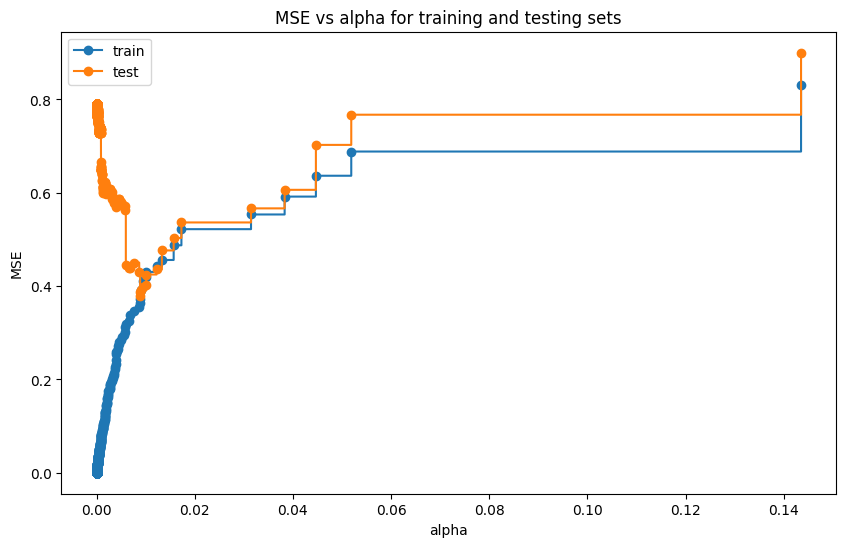

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
ax.set_xlabel("alpha")
ax.set_ylabel("MSE")
ax.set_title("MSE vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [ ]:
AA = pd.DataFrame({'node_counts':node_counts,
                   'depth': depth,
                   'train_mses': train_scores,
                   'test_mses': test_scores,
                   'ccp_alphas': ccp_alphas,
                   'cv':cv_mse})

In [ ]:
AA

,node_counts,depth,train_mses,test_mses,ccp_alphas,cv
0,1561,23,0.000000e+00,0.789824,0.000000e+00,0.712380
1,1559,23,0.000000e+00,0.789824,3.330669e-18,0.712380
2,1557,23,6.250000e-10,0.789832,6.250000e-10,0.712380
3,1555,23,1.250000e-09,0.789832,6.250000e-10,0.712380
4,1553,23,1.875000e-09,0.789832,6.250000e-10,0.712380
...,...,...,...,...,...,...
709,11,3,5.534139e-01,0.566498,3.147271e-02,0.605823
710,9,3,5.917335e-01,0.606233,3.831956e-02,0.646010
711,7,2,6.364207e-01,0.702522,4.468725e-02,0.679659
712,5,2,6.883108e-01,0.767209,5.189014e-02,0.717815


In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
print('*********Linear regression scores*********')
print('Train MSE: ', mean_squared_error(y_train, model.predict(X_train)))
print('Test MSE: ', mean_squared_error(y_test, model.predict(X_test)))

*********Linear regression scores*********
Train MSE:  0.4624747383145167
Test MSE:  0.4274379724499464


**Fully grown tree**

In [ ]:
rt = DecisionTreeRegressor(random_state=0)
rt.fit(X=X_train, y=y_train)

DecisionTreeRegressor(random_state=0)

In [ ]:
R2_train = rt.score(X_train, y_train)
R2_test = rt.score(X_test, y_test)
print('Training R2:', R2_train)
print('Test R2:', R2_test)

Training R2: 1.0
Test R2: 0.2914625379506709


In [ ]:
print('Tree depth:', rt.tree_.max_depth)
print('Tree node count:', rt.tree_.node_count)

Tree depth: 23
Tree node count: 1561


**Cost Complexity Pruning**

In [ ]:
path = rt.cost_complexity_pruning_path(X_train, y_train)

In [ ]:
ccp_alphas, impurities = path.ccp_alphas, path.impurities

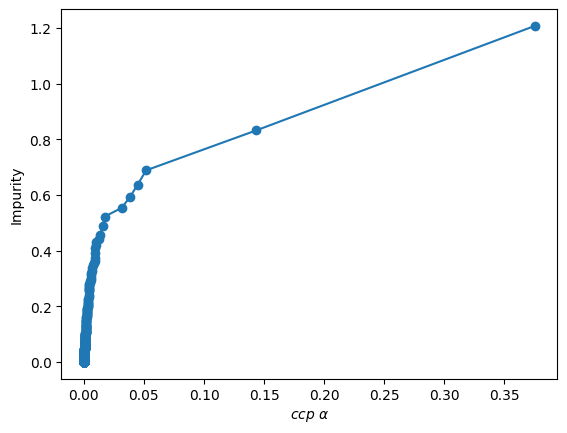

In [ ]:
plt.plot(ccp_alphas, impurities, marker = 'o')
plt.xlabel(r'$ccp~\alpha$')
plt.ylabel('Impurity')
plt.show()

In [ ]:
ccp_alphas = np.unique(ccp_alphas)[:-1]

In [ ]:
cv_r2 = []  # Store results

# Compute cross-validated avg MSE for each candidate ccp_alpha
for alpha in ccp_alphas:
    dt = DecisionTreeRegressor(random_state=0, ccp_alpha=alpha)
    scores = cross_val_score(dt, X_train, y_train, cv=KFold(5, shuffle=True, random_state=0),
                             scoring='r2', n_jobs=5)
    cv_r2.append(np.mean(scores))

In [ ]:
len(cv_r2)

714

In [ ]:
# Choose best alpha
best_alpha = ccp_alphas[np.argmax(cv_r2)]
print("Best alpha:", best_alpha)
print("maximum CV_R2:", np.max(cv_r2))

Best alpha: 0.010024541252616873
maximum CV_R2: 0.5149251673041293


Text(0, 0.5, 'Avg CV $R^2$')

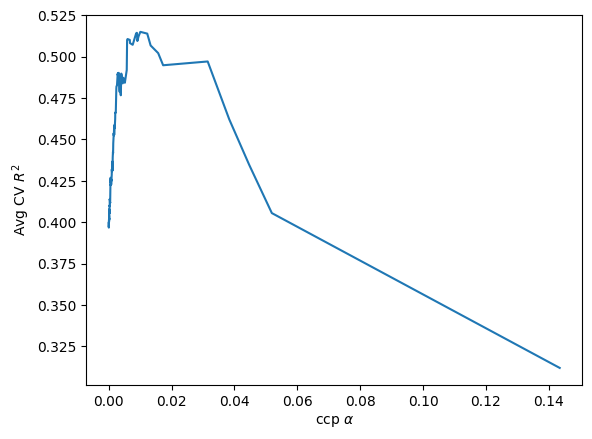

In [ ]:
plt.plot(ccp_alphas, cv_r2)
plt.xlabel(r'ccp $\alpha$'); plt.ylabel(r'Avg CV $R^2$')

In [ ]:
# Fit final model with best alpha
final_tree = DecisionTreeRegressor(random_state=0, ccp_alpha=0.01002)
final_tree.fit(X_train, y_train)

DecisionTreeRegressor(ccp_alpha=0.01002, random_state=0)

In [ ]:
print('******** Final tree results ********')
print('Training R2:', final_tree.score(X_train, y_train))
print('Test R2:', final_tree.score(X_test, y_test))
print('Tree depth:', final_tree.tree_.max_depth)
print('Tree node count:', final_tree.tree_.node_count)

******** Final tree results ********
Training R2: 0.6601317090109804
Test R2: 0.6435631488092841
Tree depth: 6
Tree node count: 29


In [ ]:
clfs = []
for alpha in ccp_alphas:
    clf = DecisionTreeRegressor(ccp_alpha=alpha, random_state=0)
    clf.fit(X_train, y_train)
    clfs.append(clf)

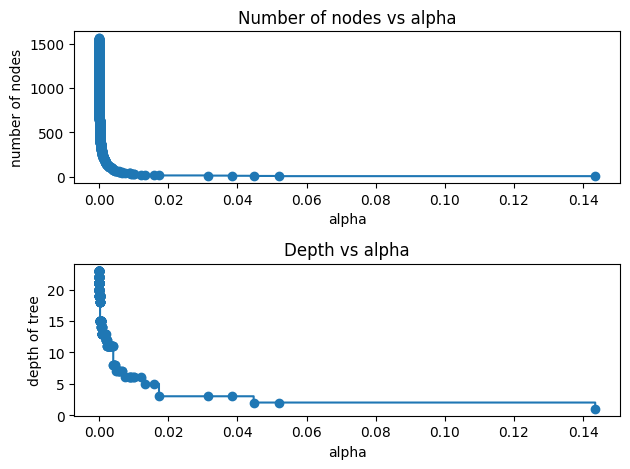

In [ ]:
fig, ax = plt.subplots(2, 1)
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

In [ ]:
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

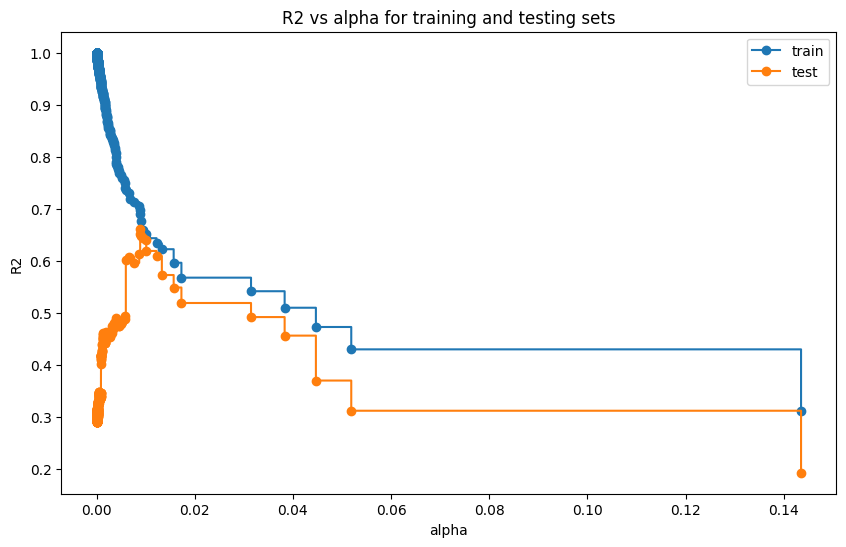

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
ax.set_xlabel("alpha")
ax.set_ylabel("R2")
ax.set_title("R2 vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [ ]:
AA = pd.DataFrame({'node_counts':node_counts,
                   'depth': depth,
                   'train_scores': train_scores,
                   'test_scores': test_scores,
                   'ccp_alphas': ccp_alphas,
                   'cv':cv_r2})
AA

,node_counts,depth,train_scores,test_scores,ccp_alphas,cv
0,1561,23,1.000000,0.291463,0.000000e+00,0.397724
1,1559,23,1.000000,0.291463,3.330669e-18,0.397724
2,1557,23,1.000000,0.291455,6.250000e-10,0.397724
3,1555,23,1.000000,0.291455,6.250000e-10,0.397724
4,1553,23,1.000000,0.291455,6.250000e-10,0.397724
...,...,...,...,...,...,...
709,11,3,0.541502,0.491805,3.147271e-02,0.497075
710,9,3,0.509754,0.456159,3.831956e-02,0.462190
711,7,2,0.472731,0.369780,4.468725e-02,0.434610
712,5,2,0.429741,0.311750,5.189014e-02,0.405478


In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
print('*********Linear regression scores*********')
print('Train R2 score: ', model.score(X_train, y_train))
print('Test R2 score: ', model.score(X_test, y_test))

*********Linear regression scores*********
Train MSE:  0.6168438179137605
Test MSE:  0.616552779642924
